In [66]:
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [67]:
ds0 = xr.open_dataset('ncqs0_hourly_pertransect.nc')  
ds1 = xr.open_dataset('ncqs1_hourly_pertransect.nc')
dp0 = xr.open_dataset('dp0_NC_10mdepth_500m.nc')
dp1 = xr.open_dataset('dp1_NC_10mdepth_500m.nc')

In [68]:
wave_lats = dp0.lat.values
wave_lons = dp0.lon.values
transect_lats = ds0.lat.values
transect_lons = ds0.lon.values

def get_nearest_indices(w_lats, w_lons, t_lats, t_lons):
    indices = []
    for lat, lon in zip(t_lats, t_lons):
        dist = np.sqrt((w_lats - lat)**2 + (w_lons - lon)**2)
        indices.append(np.argmin(dist))
    return np.array(indices)

mapping_idx = get_nearest_indices(wave_lats, wave_lons, transect_lats, transect_lons)

dp0_mapped = dp0.isel(site=mapping_idx).assign_coords(
    site=ds0.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp1_mapped = dp1.isel(site=mapping_idx).assign_coords(
    site=ds0.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

In [85]:
target_site = "usa_NC_0037_0071"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/3021740030.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/3021740030.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


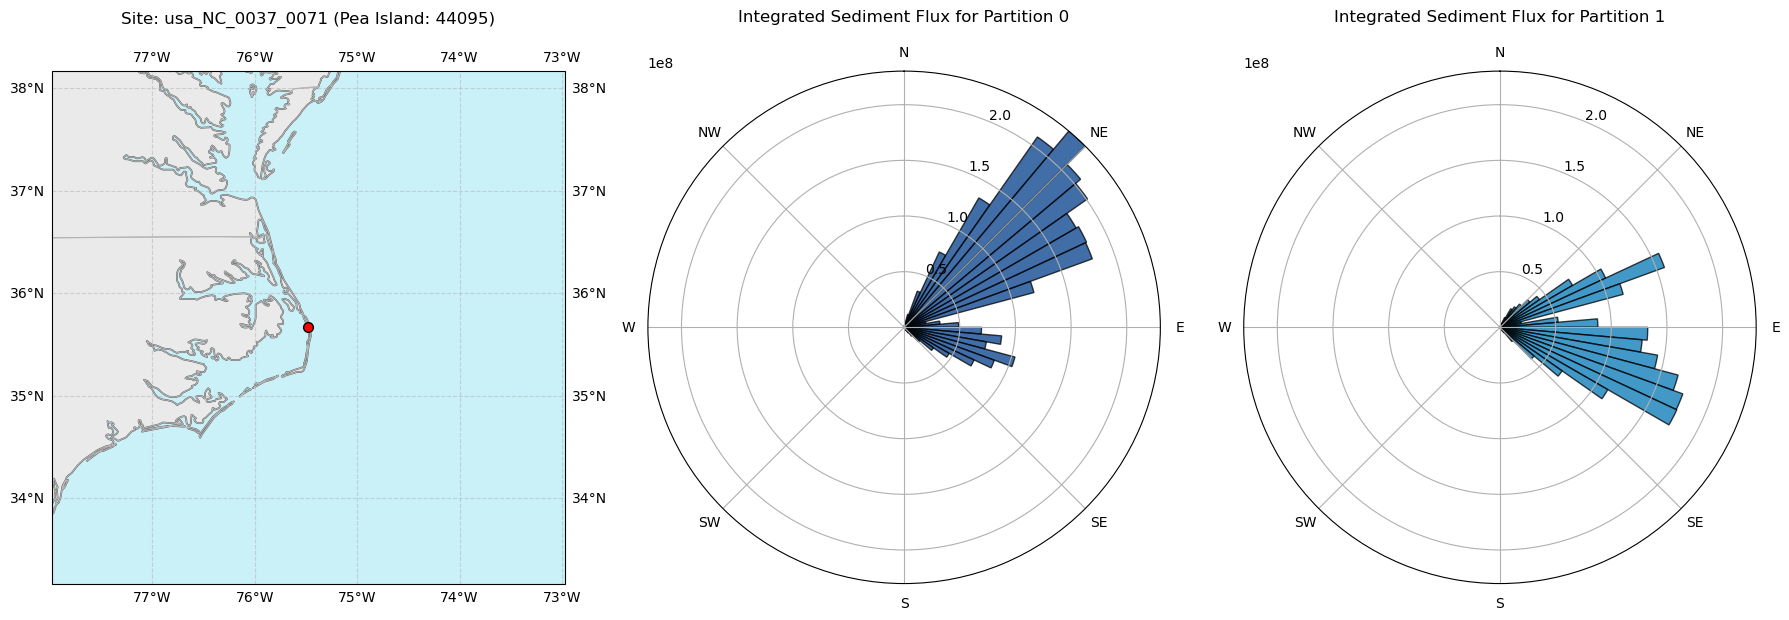

In [88]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Pea Island: 44095)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [71]:
target_site = "usa_NC_0045_0073"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/1246306500.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/1246306500.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


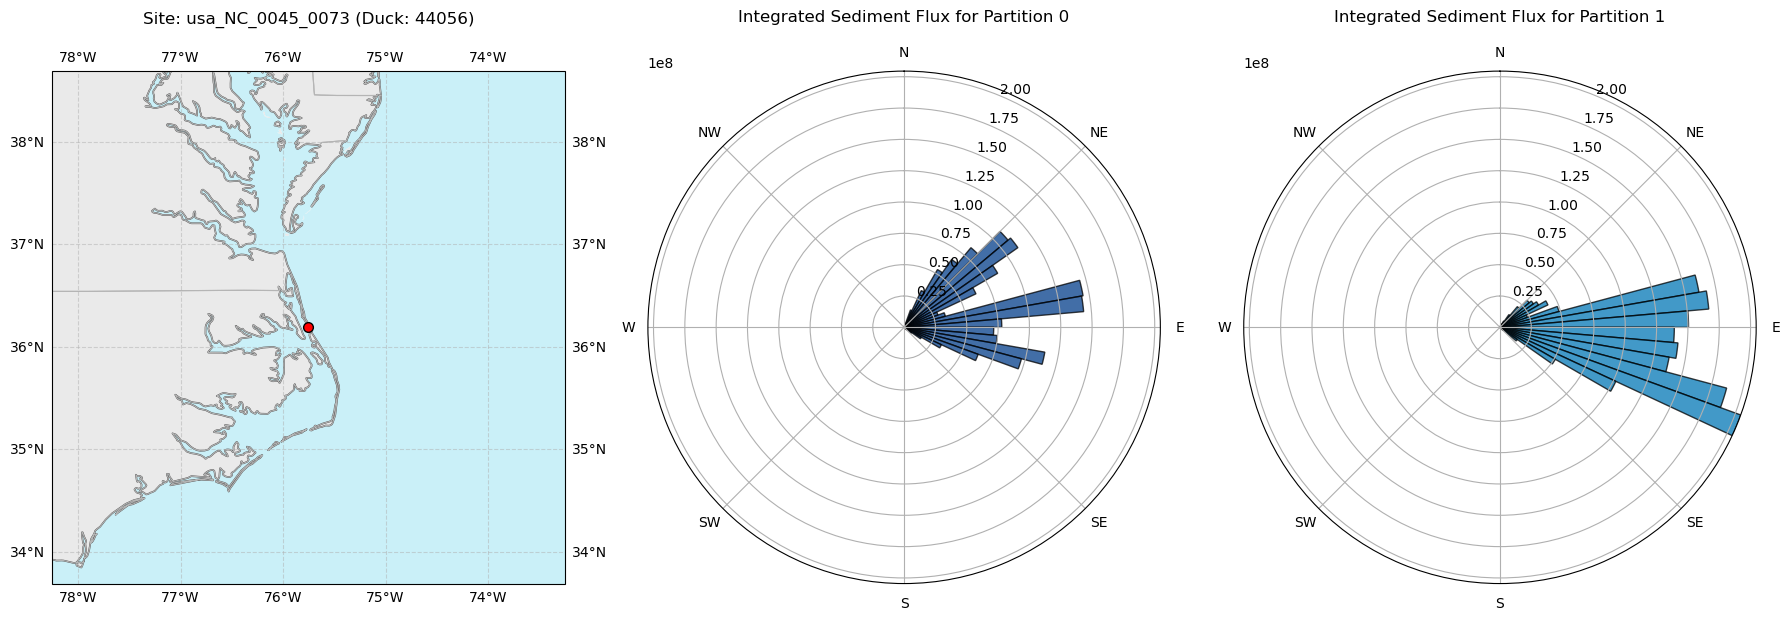

In [72]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Duck: 44056)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [73]:
target_site = "usa_NC_0040_0141"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/1960139413.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/1960139413.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


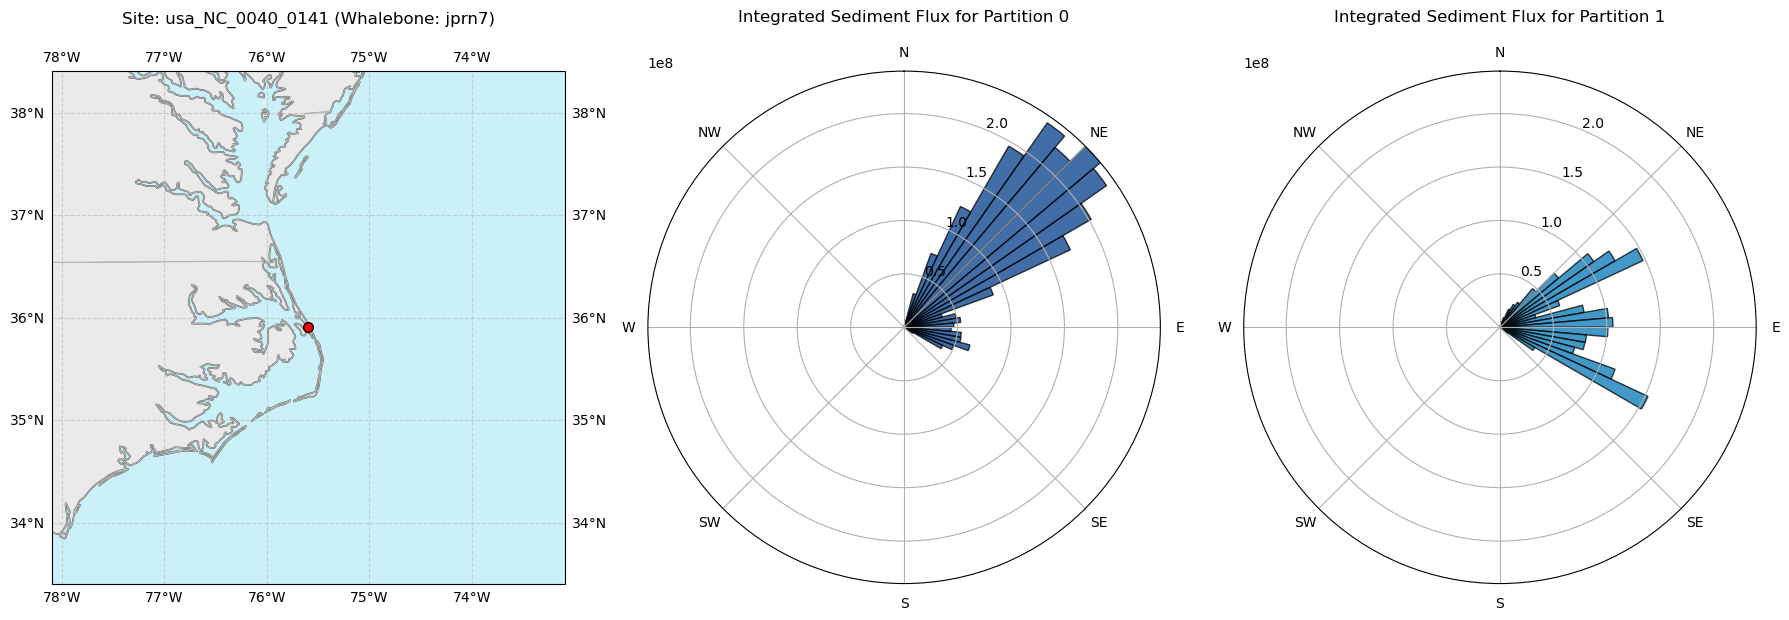

In [74]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Whalebone: jprn7)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [75]:
target_site = "usa_NC_0032_0070"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/2342329193.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/2342329193.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


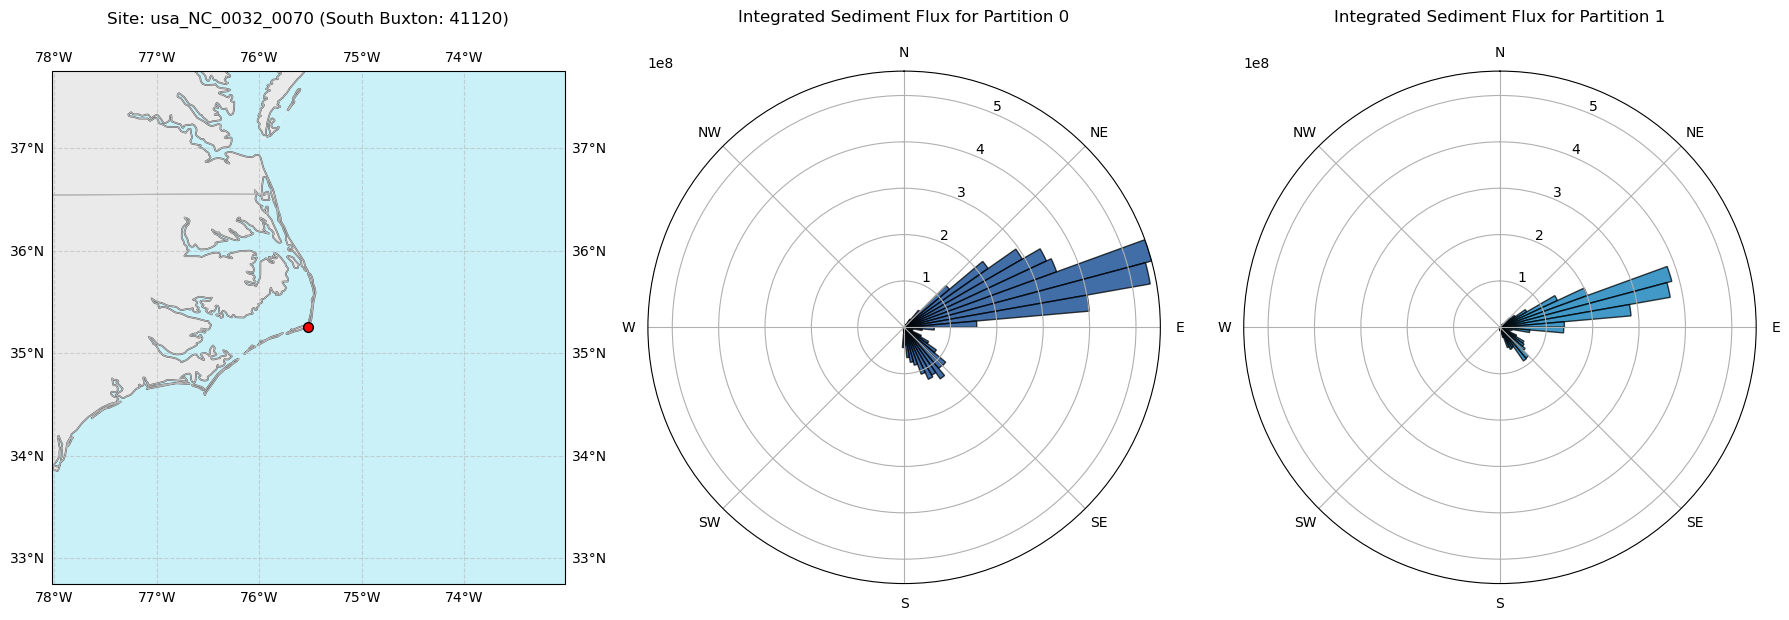

In [76]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (South Buxton: 41120)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [77]:
target_site = "usa_NC_0029_0076"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/3212404896.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/3212404896.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


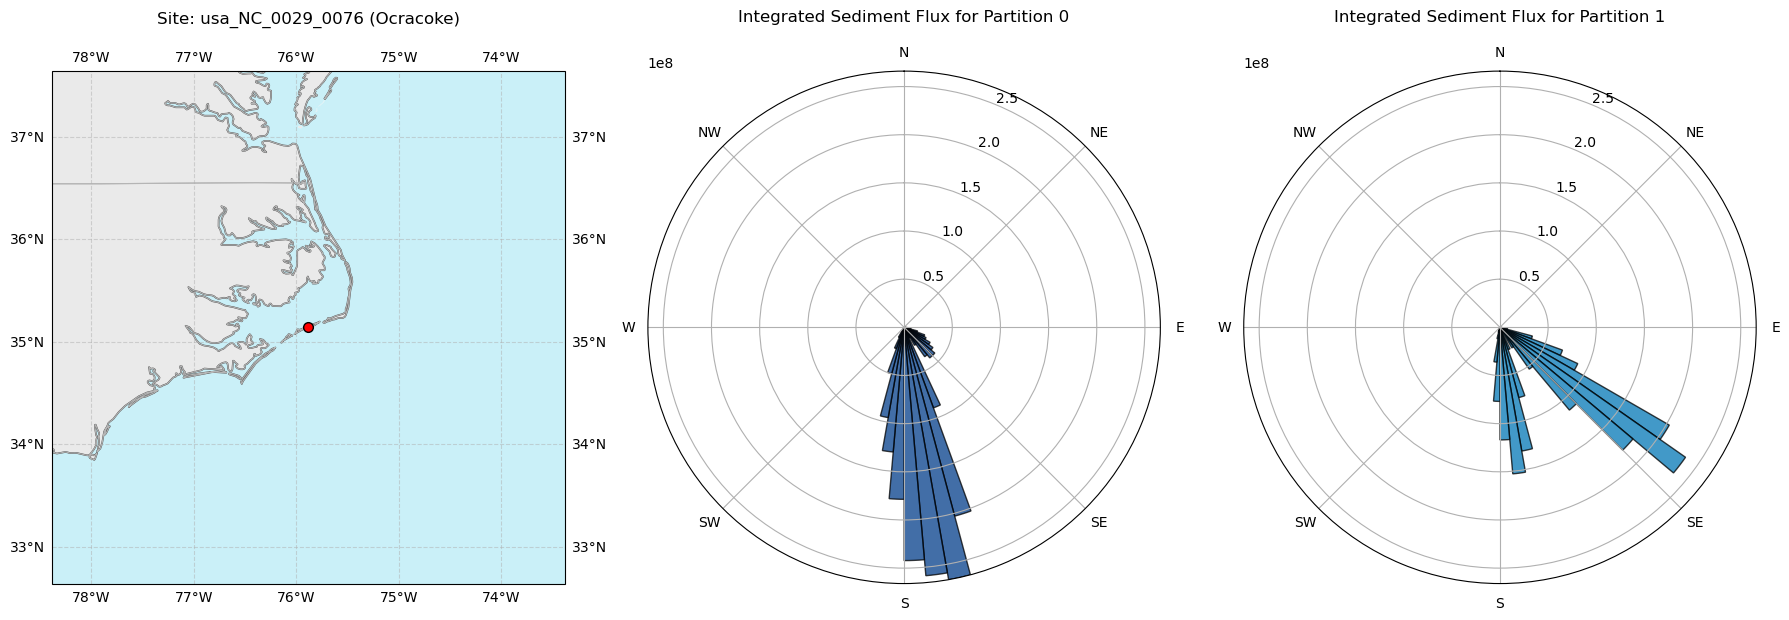

In [78]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Ocracoke)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [79]:
target_site = "usa_NC_0016_0271"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/2460444425.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/2460444425.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


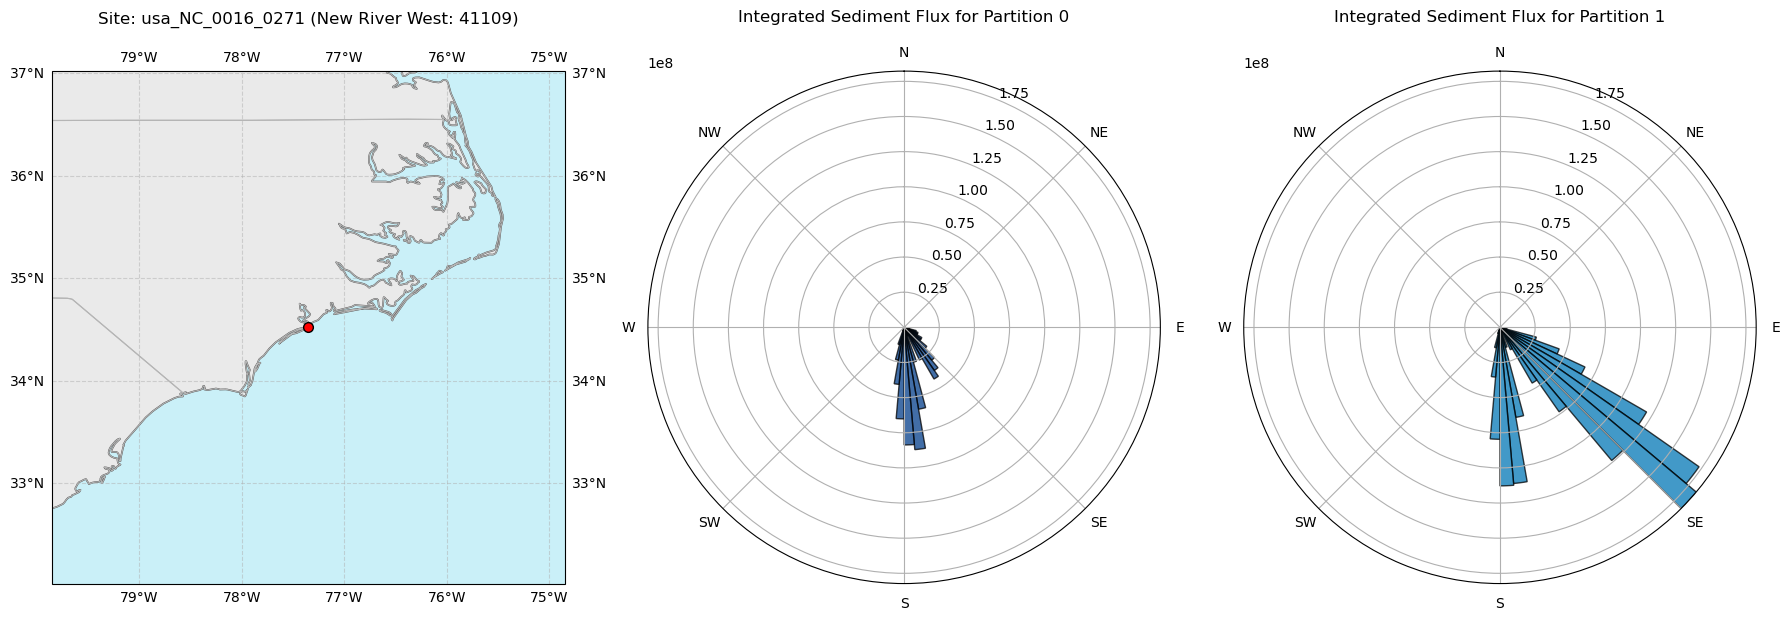

In [80]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (New River West: 41109)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [81]:
target_site = "usa_NC_0010_0136"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/719759203.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/719759203.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


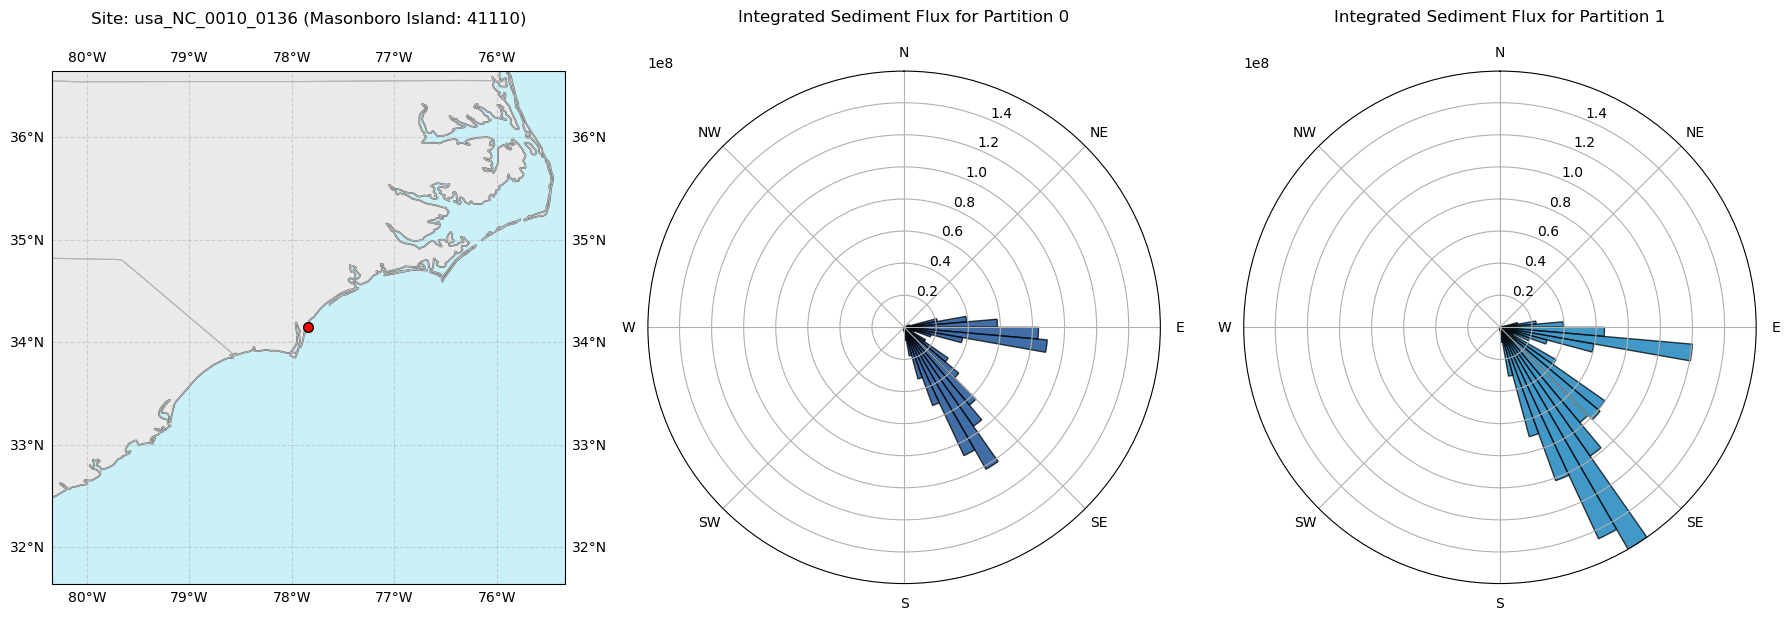

In [82]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Masonboro Island: 41110)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [83]:
target_site = "usa_NC_0001_0098"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/1422114667.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/1422114667.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


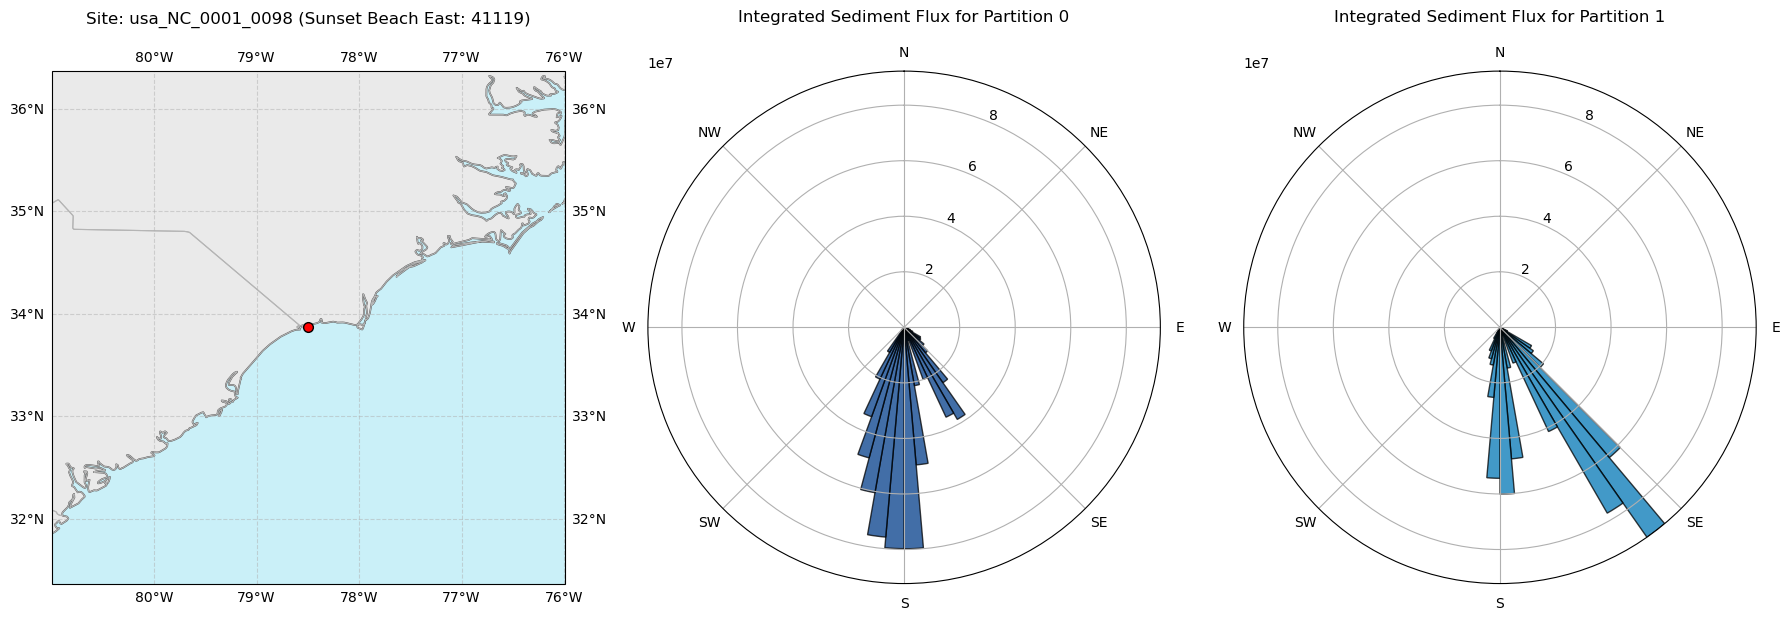

In [84]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Sunset Beach East: 41119)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()

In [89]:
target_site = "usa_NC_0031_0121"
qs_snapshot0 = ds0['qs'].sel(site=target_site).squeeze()
dp_snapshot0 = dp0_mapped['dp'].sel(site=target_site).squeeze()

qs_snapshot1 = ds1['qs'].sel(site=target_site).squeeze()
dp_snapshot1 = dp1_mapped['dp'].sel(site=target_site).squeeze()

dp_vals0 = dp_snapshot0.values.flatten()
qs_vals0 = qs_snapshot0.values.flatten()

mask = ~np.isnan(dp_vals0) & ~np.isnan(qs_vals0)
dp_vals0 = dp_vals0[mask] % 360
qs_vals0 = np.abs(qs_vals0[mask])

dp_vals1 = dp_snapshot1.values.flatten()
qs_vals1 = qs_snapshot1.values.flatten()

mask = ~np.isnan(dp_vals1) & ~np.isnan(qs_vals1)
dp_vals1 = dp_vals1[mask] % 360
qs_vals1 = np.abs(qs_vals1[mask])

bin_width = 5.0 
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = bins[:-1] + (bin_width / 2.0)

bin_indices0 = np.digitize(dp_vals0, bins)
integrated_qs0 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs0[i-1] = np.sum(qs_vals0[bin_indices0 == i])*385714

bin_indices1 = np.digitize(dp_vals1, bins)
integrated_qs1 = np.zeros(len(bin_centers))

for i in range(1, len(bins)):
    integrated_qs1[i-1] = np.sum(qs_vals1[bin_indices1 == i])*385714

angles_rad = np.deg2rad(bin_centers)
width_rad = np.deg2rad(bin_width)

qs_max = max(integrated_qs0.max(), integrated_qs1.max())

/tmp/ipykernel_112975/881132692.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
/tmp/ipykernel_112975/881132692.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])


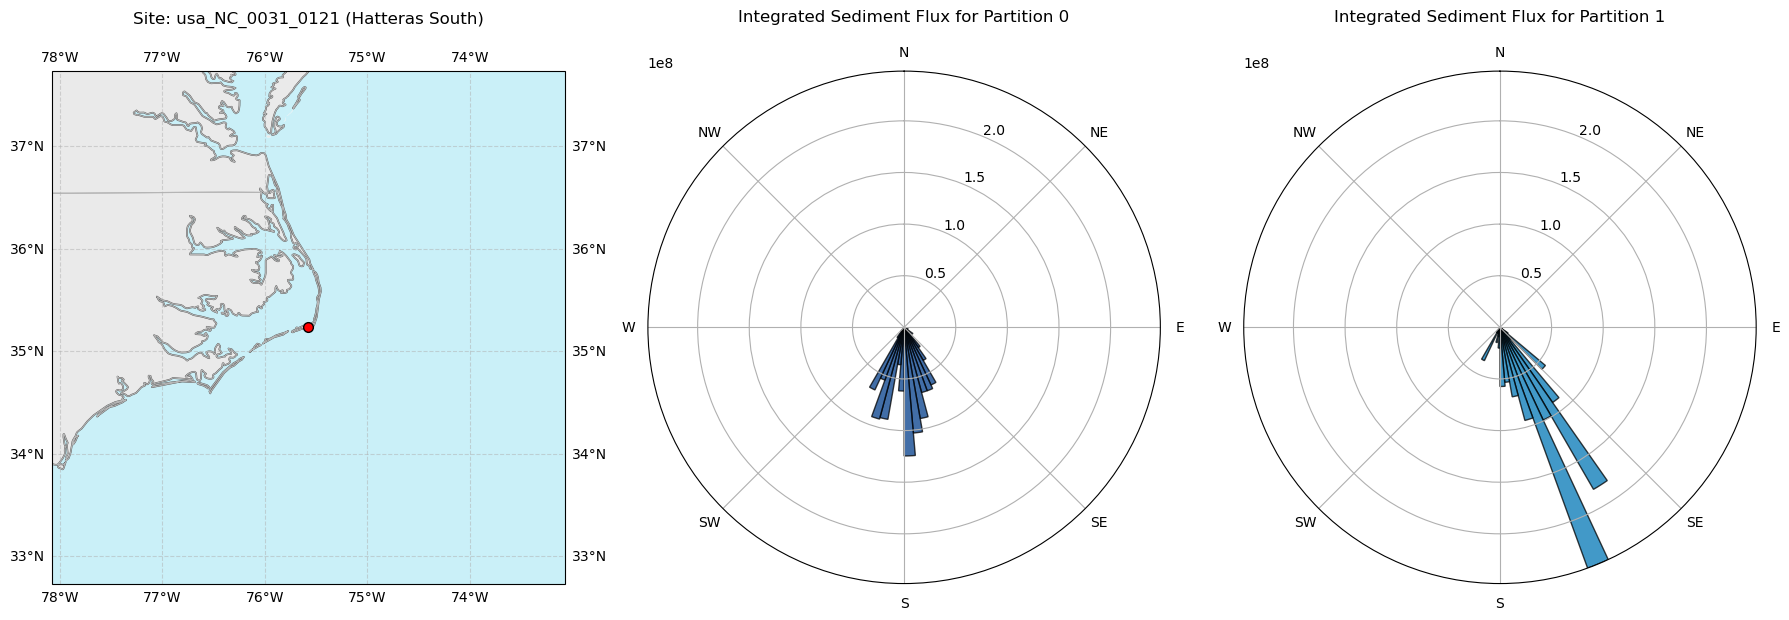

In [98]:
fig = plt.figure(figsize=(18, 6))

ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree()) 
ax1 = fig.add_subplot(1, 3, 2, projection='polar') 
ax2 = fig.add_subplot(1, 3, 3, projection='polar')                     

ax = [ax0, ax1, ax2]

site_lon = float(ds0['lon'].sel(site=target_site).values)
site_lat = float(ds0['lat'].sel(site=target_site).values)

ax[0].add_feature(cfeature.LAND, facecolor='#eaeaea')
ax[0].add_feature(cfeature.OCEAN, facecolor='#caf0f8')
ax[0].add_feature(cfeature.COASTLINE, edgecolor='#4a4a4a', linewidth=1.2)
ax[0].add_feature(cfeature.STATES, edgecolor='#b5b5b5', linewidth=0.8)

ax[0].set_extent([site_lon - 2.5, site_lon + 2.5, site_lat - 2.5, site_lat + 2.5], crs=ccrs.PlateCarree())

ax[0].plot(site_lon, site_lat, color='red', marker='.', markersize=14, 
           markeredgecolor='black', transform=ccrs.PlateCarree(), label='Target Site')

ax[0].set_title(f'Site: {target_site} (Hatteras South)', pad=20)
ax[0].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)

bars0 = ax[1].bar(
    angles_rad, 
    integrated_qs0, 
    width=width_rad, 
    bottom=0.0, 
    color='#023e8a', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[1].set_theta_zero_location('N') 
ax[1].set_theta_direction(-1)       

ax[1].set_title(f'Integrated Sediment Flux for Partition 0', pad=17)
ax[1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[1].set_rlim(0, qs_max)

bars1 = ax[2].bar(
    angles_rad, 
    integrated_qs1, 
    width=width_rad, 
    bottom=0.0, 
    color='#0277b6', 
    edgecolor='black', 
    alpha=0.75
)

# plot in bearing space
ax[2].set_theta_zero_location('N') 
ax[2].set_theta_direction(-1)       

ax[2].set_title(f'Integrated Sediment Flux for Partition 1', pad=17)
ax[2].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax[2].set_rlim(0, qs_max)

plt.tight_layout()
plt.show()